In [ ]:
import os, sys, importlib, pathlib
from pathlib import Path
import pandas as pd
import geopandas as gpd
sys.path.append(os.path.abspath(".."))
import matplotlib.pyplot as plt

# my utils
from utils import geoplot
gdf_joined=gpd.read_file("../data_geo\Q1Q2Q3\listings_paris2406_geo.gpkg")
print(len(gdf_joined))
print(gdf_joined.columns.to_list())


## output
OUTPUT_FOLDER_MAP=Path("../output_map1/changed_host")


62738
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'ava

## préparer les données:

In [3]:
gdf_joined_Q1=gpd.read_file("../data_geo\Q1Q2Q3\listings_paris2403_geo.gpkg")
gdf_joined_Q2=gpd.read_file("../data_geo\Q1Q2Q3\listings_paris2406_geo.gpkg")
gdf_joined_Q3=gpd.read_file("../data_geo\Q1Q2Q3\listings_paris2409_geo.gpkg")

dict_gdf_joined={'2403':gdf_joined_Q1,
                 '2406':gdf_joined_Q2,
                 '2409':gdf_joined_Q3}

print(dict_gdf_joined.keys())


dict_keys(['2403', '2406', '2409'])


## détecter la présence de jo/sites touristiques

In [4]:
list_jo = [
    r"\bjo\b",
    r"\bolympique(s)?\b",
    r"\bolympics(s)?\b",    
    r"\bstade\b",
    r"\barena\b",    
    r"\bcentre cquatique\b",    
    r"\bomnisports\b",
    r"\bsport(s)?\b",
    r"\bsportif(s)?\b",
    r"\bgames\b",

]

list_tourism = [
    # Montmartre
    r"\bmontmartre\b",
    r"\bsacr[eé][ -]?coeur\b",
    # Le Marais
    r"\ble marais\b",
    r"\bmarais\b",
    r"\bplace des vosges\b",

    # Opéra / Grands Boulevards
    r"\bop[eé]ra\b",
    r"\bpalais garnier\b",
    r"\bgalleries? lafayette\b",
    r"\bprintemps haussmann\b",

    # Louvre / Rivoli
    r"\blouvre\b",
    r"\bmus[eé]e du louvre\b",
    r"\brue de rivoli\b",

    # Eiffel Tower / Trocadéro
    r"\beiffel tower\b",
    r"\btour eiffel\b",
    r"\btrocad[eé]ro\b",
    r"\bchamp de mars\b",

    # Champs-Élysées
    r"\bchamps[- ]elys[eé]es\b",
    r"\bavenue des champs[- ]elys[eé]es\b",
    r"\bplace de la concorde\b",

    # Latin Quarter
    r"\blatin quarter\b",
    r"\bquartier latin\b",
    r"\bpanth[eé]on\b",
    r"\bsorbonne\b",

    # Notre-Dame / Île de la Cité
    r"\bnotre[- ]dame\b",
    r"\bnotre[- ]dame de paris\b",
    r"\bile de la cit[eé]\b",

    # Saint-Germain-des-Prés
    r"\bsaint[- ]germain[- ]des[- ]pr[eé]s\b",
    r"\bst germain\b",

    # Canal Saint-Martin
    r"\bcanal saint[- ]martin\b",

    # Invalides
    r"\binvalides\b",
    r"\bh[oô]tel des invalides\b",

    # Grand monuments
    r"\bgrand palais\b",
    r"\bpetit palais\b",
    r"\bcentre pompidou\b",
    r"\bbeaubourg\b"
]


import re

dict_gdf_joiend_mention={}
for ym, gdf_joined in dict_gdf_joined.items():   
    text_cols=['description','neighborhood_overview',"host_about"]
    gdf_joined["text_all"] = (
        gdf_joined[text_cols]
        .fillna("")
        .agg(" ".join, axis=1)
    )
    #---------------------------------------------------------------------
    
    pattern_jo = "|".join(list_jo)
    gdf_joined["mention_jo"] = (
        gdf_joined["text_all"]
        .str.lower()
        .str.contains(pattern_jo, regex=True, na=False)
        .astype(int)
    )
    # print(gdf_joined.mention_jo.value_counts(dropna=False))


    # ---------------------------------------------------------------------
    pattern_tourism= "|".join(list_tourism)
    gdf_joined["mention_tourism"] = (
        gdf_joined["text_all"]
        .str.lower()
        .str.contains(pattern_tourism, regex=True, na=False)
        .astype(int)
    )
    # print(gdf_joined.mention_toursim.value_counts(dropna=False))
    dict_gdf_joiend_mention[ym]=gdf_joined

C:\Users\yeliu\AppData\Local\Temp\ipykernel_11852\2984313069.py:90: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gdf_joined["text_all"]
C:\Users\yeliu\AppData\Local\Temp\ipykernel_11852\2984313069.py:90: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gdf_joined["text_all"]
C:\Users\yeliu\AppData\Local\Temp\ipykernel_11852\2984313069.py:90: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  gdf_joined["text_all"]


## proportion 'mention_jo'& 'mention_tourism'

In [ ]:
for ym, gdf in dict_gdf_joiend_mention.items():
    print(ym, len(gdf))
    print(gdf['mention_jo'].value_counts(dropna=False)/len(gdf))
    print(gdf['mention_jo'].value_counts(dropna=False))
    print(gdf['mention_tourism'].value_counts(dropna=False)/len(gdf),"\n")

2403 40865
mention_jo
0    0.941857
1    0.058143
Name: count, dtype: float64
mention_jo
0    38489
1     2376
Name: count, dtype: int64
mention_tourism
1    0.562609
0    0.437391
Name: count, dtype: float64 

2406 62738
mention_jo
0    0.919538
1    0.080462
Name: count, dtype: float64
mention_jo
0    57690
1     5048
Name: count, dtype: int64
mention_tourism
1    0.544869
0    0.455131
Name: count, dtype: float64 

2409 48064
mention_jo
0    0.933547
1    0.066453
Name: count, dtype: float64
mention_jo
0    44870
1     3194
Name: count, dtype: int64
mention_tourism
1    0.552534
0    0.447466
Name: count, dtype: float64 



## T2 2024: proportion 'mention_jo'& 'mention_tourism' sur hôtes en changement

In [ ]:
gdf_joined=dict_gdf_joiend_mention["2406"]
gdf=gdf_joined[gdf_joined["is_changed"]==1]

print(ym, len(gdf_joined), len(gdf))
print(gdf['mention_jo'].value_counts(dropna=False)/len(gdf))
print(gdf['mention_tourism'].value_counts(dropna=False)/len(gdf),"\n")


2403 62738 29097
mention_jo
0    0.898752
1    0.101248
Name: count, dtype: float64
mention_tourism
1    0.508334
0    0.491666
Name: count, dtype: float64 



## STATS : T2 2024: 
### Porportion des superhost / pro host sur des hôtes qui mentionnent JO/ sites touristiques

In [73]:
gdf_joined=dict_gdf_joiend_mention["2406"]
gdf_jo=gdf_joined[gdf_joined["mention_jo"]==1]
gdf_tourism=gdf_joined[gdf_joined["mention_tourism"]==1]

gdf=gdf_jo.copy()
print("MENTION JO:")
print(gdf['is_changed'].value_counts(dropna=False)/len(gdf))
print(gdf['status'].value_counts(dropna=False)/len(gdf))
print(gdf['host_is_superhost'].value_counts(dropna=False)/len(gdf))
print(gdf['professional_host'].value_counts(dropna=False)/len(gdf),"\n")


gdf=gdf_tourism.copy()
print("MENTION SITES")
print(gdf['is_changed'].value_counts(dropna=False)/len(gdf))
print(gdf['status'].value_counts(dropna=False)/len(gdf))
print(gdf['host_is_superhost'].value_counts(dropna=False)/len(gdf))
print(gdf['professional_host'].value_counts(dropna=False)/len(gdf),"\n")



MENTION JO:
is_changed
1    0.583597
0    0.416403
Name: count, dtype: float64
status
old_host         0.503170
reopen_host      0.272385
reactive_host    0.193740
new_host         0.030705
Name: count, dtype: float64
host_is_superhost
f    0.838946
t    0.161054
Name: count, dtype: float64
professional_host
0    0.753764
1    0.246236
Name: count, dtype: float64 

MENTION SITES
is_changed
0    0.567312
1    0.432688
Name: count, dtype: float64
status
old_host         0.670138
reopen_host      0.182278
reactive_host    0.118096
new_host         0.029487
Name: count, dtype: float64
host_is_superhost
f    0.773754
t    0.226246
Name: count, dtype: float64
professional_host
0    0.62813
1    0.37187
Name: count, dtype: float64 



## vis:

[INFO] cbar takes bounds: quantile!


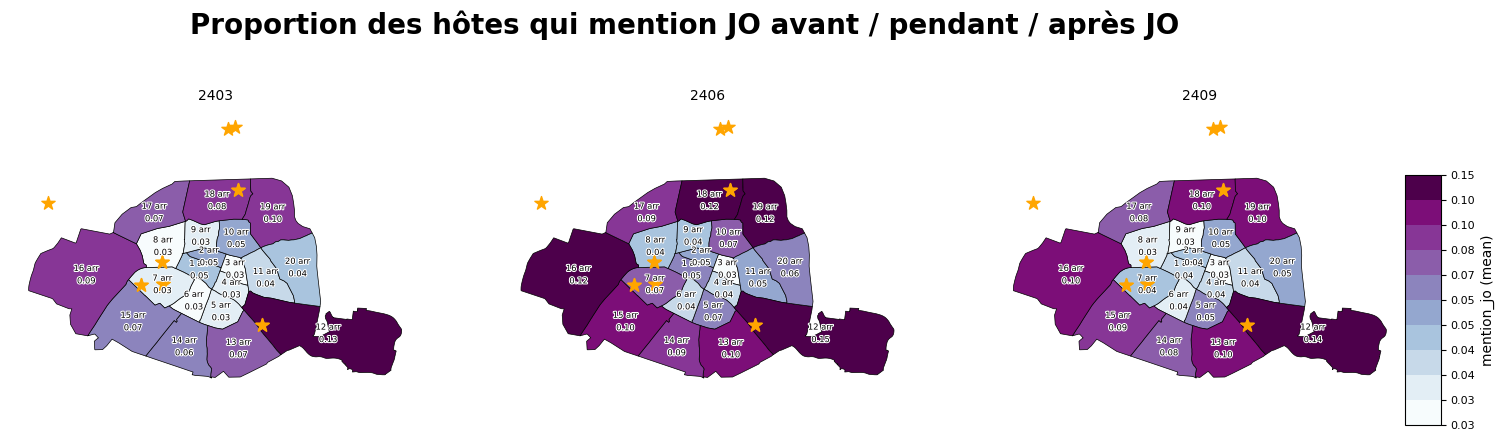

In [68]:
importlib.reload(geoplot)
from utils.geoplot import layout_comparison_indep

gdf_map=gpd.read_file("../data_map\paris_ar.gpkg")
gdf_venues=gpd.read_file("../data_geo\main_venues_JO.gpkg")


layout_comparison_indep(dict_gdf_joined=dict_gdf_joiend_mention, gdf_map=gdf_map,
                gdf_venues=gdf_venues,
                col='mention_jo', way='mean', groupby="c_ar",
                scheme="quantile", vmin=None, vmax=None, k_quantile=10, bins=None, cmap="BuPu",#"PuBu",#"BuPu",
                color_text="black", color_star='orange',
                suptitle="Proportion des hôtes qui mention JO avant / pendant / après JO", loc="paris", # for filename
                n_axes=3, n_cols=3,#每行最多几张（列）
                save=False, output_folder=None, filename=None)



mention_tourism
1    34184
0    28554
Name: count, dtype: int64
[INFO] cbar takes bounds: quantile!


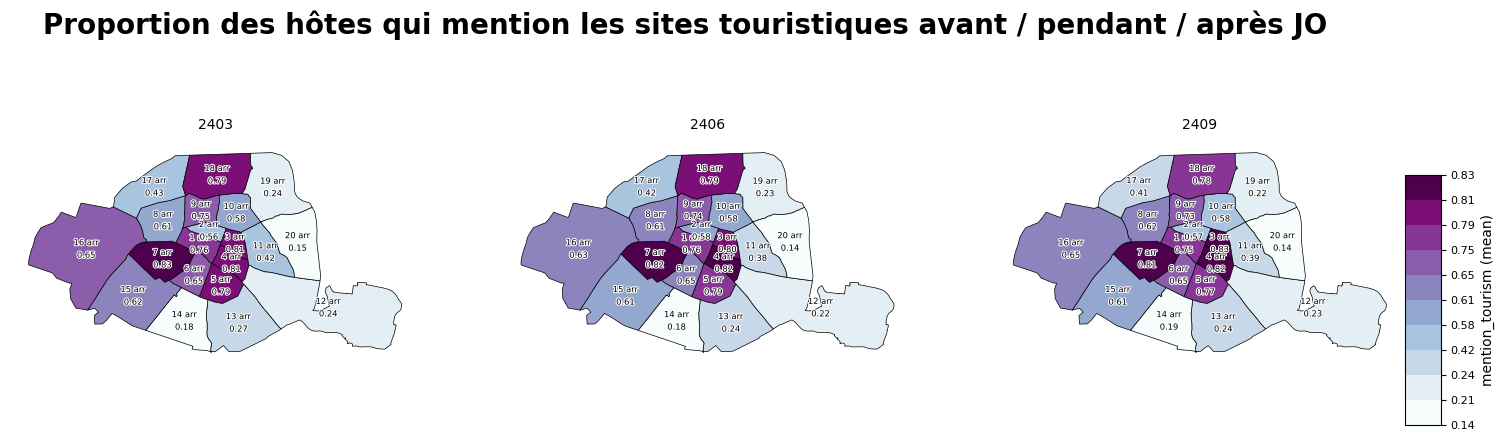

In [69]:

importlib.reload(geoplot)
from utils.geoplot import layout_comparison_indep, layout_comparison_indep
print(dict_gdf_joiend_mention['2406']['mention_tourism'].value_counts())


layout_comparison_indep(dict_gdf_joined=dict_gdf_joiend_mention, gdf_map=gdf_map,
                gdf_venues=None,
                col='mention_tourism', way='mean', groupby="c_ar",
                scheme="quantile", vmin=None, vmax=None, k_quantile=10, bins=None, cmap="BuPu",
                color_text="black", color_star='orange',
                suptitle="Proportion des hôtes qui mention les sites touristiques avant / pendant / après JO", loc="paris", # for filename
                n_axes=3, n_cols=3,#每行最多几张（列）
                save=False, output_folder=None, filename=None)


# layout_comparison_indep2(dict_gdf_joined=dict_gdf_joiend_mention, 
#                 gdf_map=gdf_map,
#                 gdf_venues=None, add_buffer_m=0,
#                 col="mention_tourism", groupby="c_ar", k=1, 
#                 suptitle="Part des hôtes qui mentionnent des sites touristiques par arrondissement", 
#                 loc="paris", # just for filename
#                 n_axes=3, n_cols=3,#每行最多几张（列）
#                 save=True, output_folder="../output_map/bio", filename="comparaison_mention_tourism.jpg")
